# Gradient Domain Editing

## Đọc và hiển thị ảnh

Ghép cá sấu từ `images/image_3.png` vào hồ bơi trong `images/image_1.jpg`.

- `target`: ảnh nền, dạng BGR.
- `source`: ảnh nguồn, dạng BGR.


In [271]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


### Đọc ảnh BGR


In [272]:
target_path = 'images/image_1.jpg'
source_path = 'images/image_3.png'
target = cv2.imread(target_path)
source = cv2.imread(source_path)


### Xem thông số của ảnh

In [273]:
{
    'target': (target.shape, target.dtype, target.min(), target.max()),
    'source': (source.shape, source.dtype, source.min(), source.max())
}

{'target': ((981, 736, 3), dtype('uint8'), np.uint8(0), np.uint8(255)),
 'source': ((1086, 1448, 3), dtype('uint8'), np.uint8(0), np.uint8(255))}

### Đổi BGR sang RGB

OpenCV đọc BGR, còn Matplotlib hiển thị RGB. Đổi thứ tự kênh trước khi hiển thị để màu đúng.


In [274]:
target_rgb = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)
source_rgb = cv2.cvtColor(source, cv2.COLOR_BGR2RGB)


### Hiển thị hai ảnh gốc


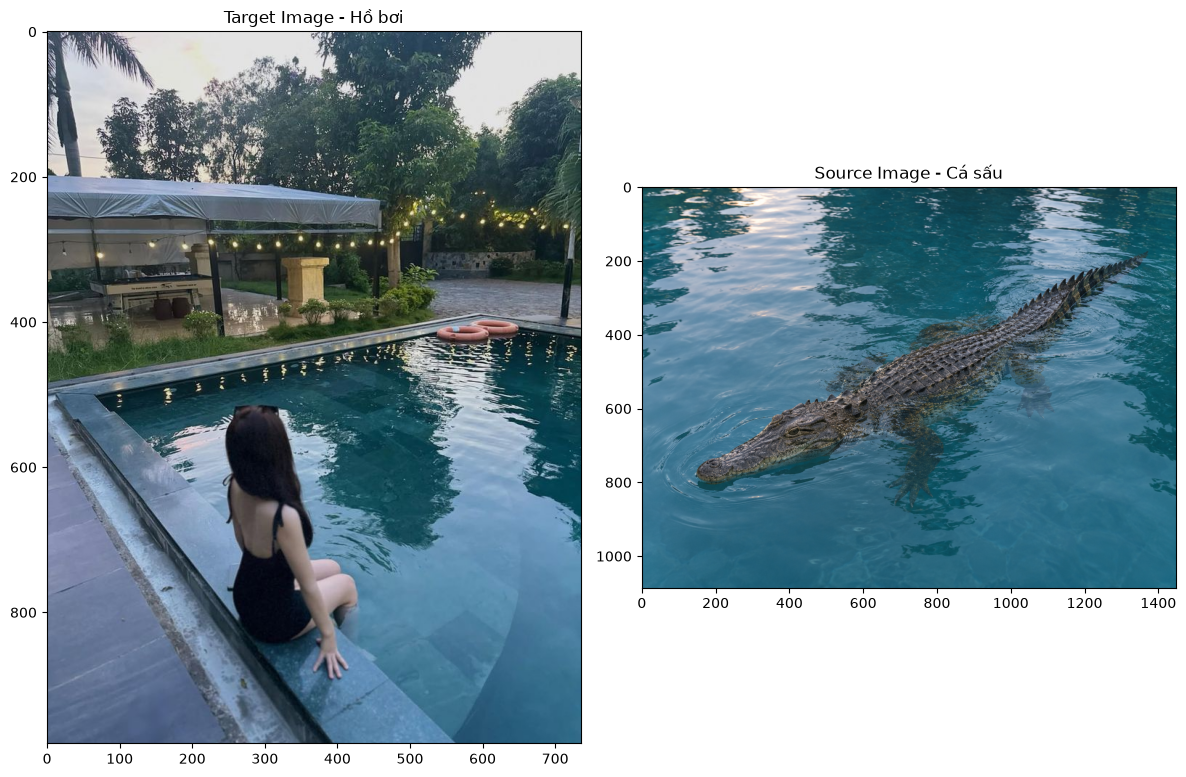

In [275]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

axes[0].imshow(target_rgb)
axes[0].set_title('Target Image - Hồ bơi')
axes[1].imshow(source_rgb)
axes[1].set_title('Source Image - Cá sấu')

plt.tight_layout()
plt.show()

## Chọn kích thước trước khi vẽ mask

Ảnh nguồn rộng hơn ảnh nền nên cần thu nhỏ để cá sấu vừa vùng nước. Hai ảnh không cần cùng kích thước.

- Input: `target`, `source` là hai ảnh gốc BGR.
- Output: `target_small`, `source_small` là hai ảnh RGB sau resize.

Thử cạnh dài nền bằng 800 pixel và chiều rộng nguồn bằng 320 pixel. Chiều rộng cá sấu sẽ nhỏ hơn chiều rộng toàn bộ ảnh nguồn.

Giữ tỷ lệ bằng cách nhân cả chiều cao và chiều rộng với cùng một hệ số `scale`. Dùng `round` để lấy kích thước nguyên và `INTER_AREA` khi thu nhỏ.

`cv2.resize` nhận **(W, H)**; `shape` trả về **(H, W, C)**.


In [276]:
target_size = 800
source_width = 320


### Resize ảnh nền và ảnh nguồn


In [277]:
h_t, w_t = target.shape[0:2]
scale = target_size / max(h_t, w_t)
target_small = cv2.resize(target_rgb, (round(w_t * scale), round(h_t * scale)), interpolation=cv2.INTER_AREA)

h_s, w_s = source.shape[0:2]
scale = source_width / w_s
source_small = cv2.resize(source_rgb, (source_width, round(h_s * scale)), interpolation=cv2.INTER_AREA)


### Kiểm tra kích thước sau resize


In [278]:
{'target': target_small.shape, 'source': source_small.shape}

{'target': (800, 600, 3), 'source': (240, 320, 3)}

### Đọc tọa độ trên ảnh sau resize

Hai cell tiếp theo hiển thị riêng ảnh nguồn và ảnh nền với lưới tọa độ. Hai hình được phóng to độc lập để dễ quan sát; đọc trục pixel khi so kích thước.

- Điểm trên hình viết `(x, y)`; truy cập mảng viết `source_small[y, x]`.
- Tọa độ mask lấy trên ảnh nguồn đã resize. Nếu đổi kích thước nguồn, cần cập nhật mask.

Lần đầu có thể chọn phần mõm, thân và đuôi nổi rõ; để chân chìm có biên mờ ngoài mask. Giữ vùng nước xung quanh trong ảnh nguồn để tính gradient tại biên.


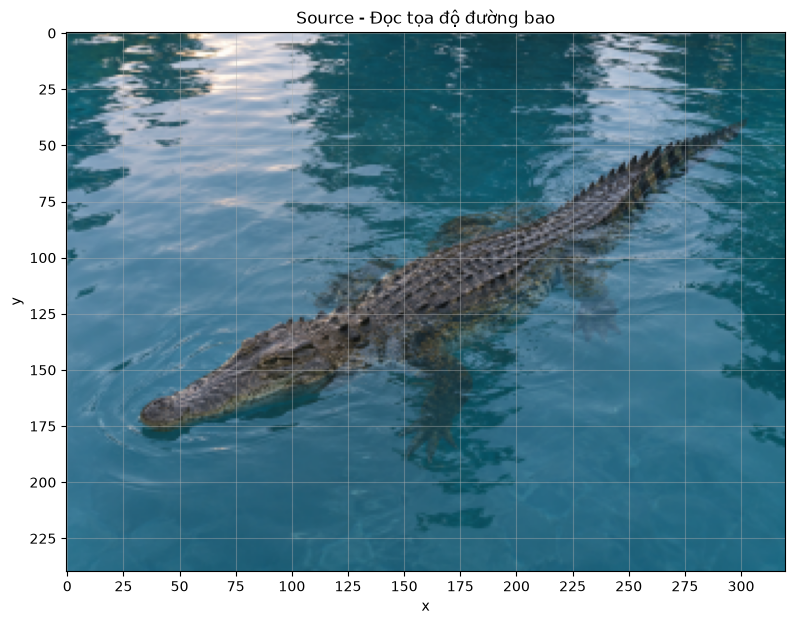

In [279]:
plt.figure(figsize=(10, 7))
plt.imshow(source_small)
plt.xticks(np.arange(0, source_small.shape[1], 25))
plt.yticks(np.arange(0, source_small.shape[0], 25))
plt.grid(alpha=0.4)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Source - Đọc tọa độ đường bao')
plt.show()


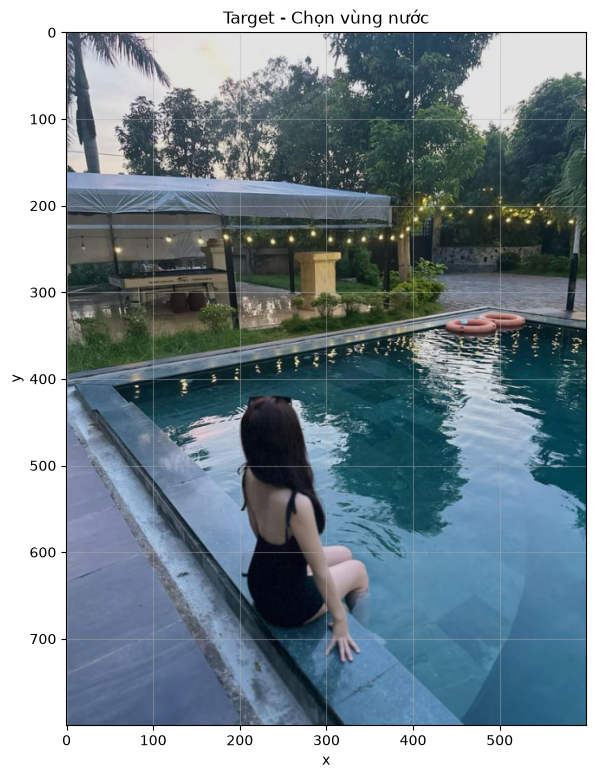

In [280]:
plt.figure(figsize=(7, 9))
plt.imshow(target_small)
plt.xticks(np.arange(0, target_small.shape[1], 100))
plt.yticks(np.arange(0, target_small.shape[0], 100))
plt.grid(alpha=0.4)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Target - Chọn vùng nước')
plt.show()


## Tạo mask cá sấu

Mask là ảnh một kênh, cùng chiều cao và chiều rộng với `source_small`:

- `255`: vùng chọn để ghép.
- `0`: vùng không chọn.

**Input:** `source_small` và các điểm đường bao `points`. 
**Output:** `mask` có kiểu `uint8`.


### Chọn các điểm đường bao

Mỗi điểm viết `(x, y)` trên ảnh nguồn đã resize rộng 320 pixel. Các điểm đi liên tiếp quanh cá sấu; không nối các điểm theo thứ tự ngẫu nhiên.

Đường bao bên dưới là lựa chọn ban đầu quanh phần nổi, để bạn xem và điều chỉnh. Chưa chọn chân chìm. Nếu đổi `source_width`, cần chọn lại tọa độ.

In [281]:
points = np.array([
    (32, 170), (40, 159), (63, 142), (88, 130),
    (112, 124), (137, 105), (163, 84), (190, 77),
    (213, 65), (237, 55), (262, 49), (284, 41),
    (304, 38), (292, 50), (275, 65), (251, 79),
    (231, 92), (219, 109), (190, 127), (166, 137),
    (140, 146), (117, 154), (96, 166), (67, 176),
    (38, 179)
], dtype=np.int32)


### Tạo mask từ đa giác

`np.zeros` tạo mask ban đầu toàn 0. `cv2.fillPoly` nối các điểm, đóng đường bao và tô vùng bên trong bằng 255. `points` dùng `int32` vì tọa độ là số nguyên.

Chỉ tạo mask; giữ nguyên các pixel nước quanh cá sấu trong `source_small` để tính gradient ở bước sau.


In [282]:
mask = np.zeros(source_small.shape[0:2], dtype=np.uint8)
mask = cv2.fillPoly(mask, [points], 255)

### Kiểm tra shape, dtype và giá trị mask


In [283]:
mask.shape, mask.dtype, np.unique(mask)


((240, 320), dtype('uint8'), array([  0, 255], dtype=uint8))

### Hiển thị mask: trắng là vùng chọn, đen là vùng ngoài


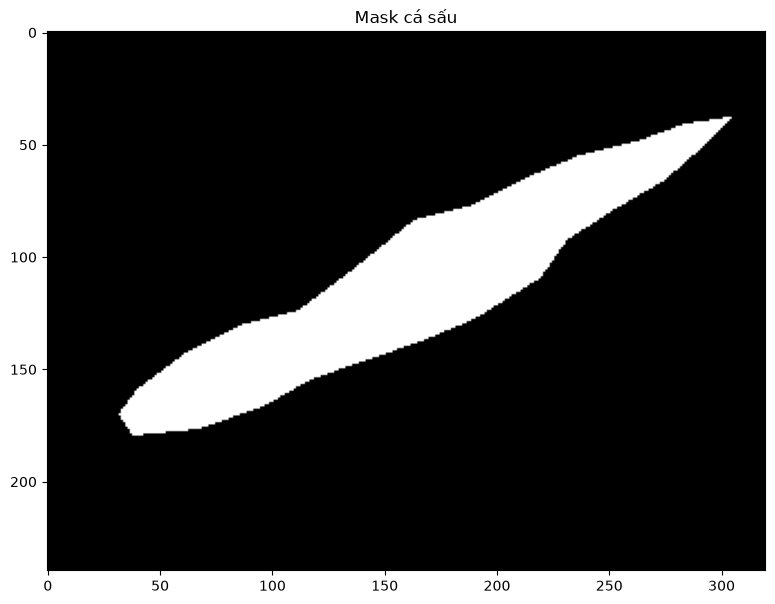

In [284]:
plt.figure(figsize=(10, 7))
plt.imshow(mask, cmap='gray', vmin=0, vmax=255)
plt.title('Mask cá sấu')
plt.show()


### Kiểm tra vùng chọn trên ảnh nguồn

Lớp màu cam là vùng trong mask; các chấm đỏ là các điểm đường bao. `np.ma.masked_where` ẩn vùng mask bằng 0 khi vẽ, để vùng nước ngoài mask không bị phủ màu.

`alpha=0.35` làm lớp cam trong suốt một phần để nhìn được cá sấu bên dưới.


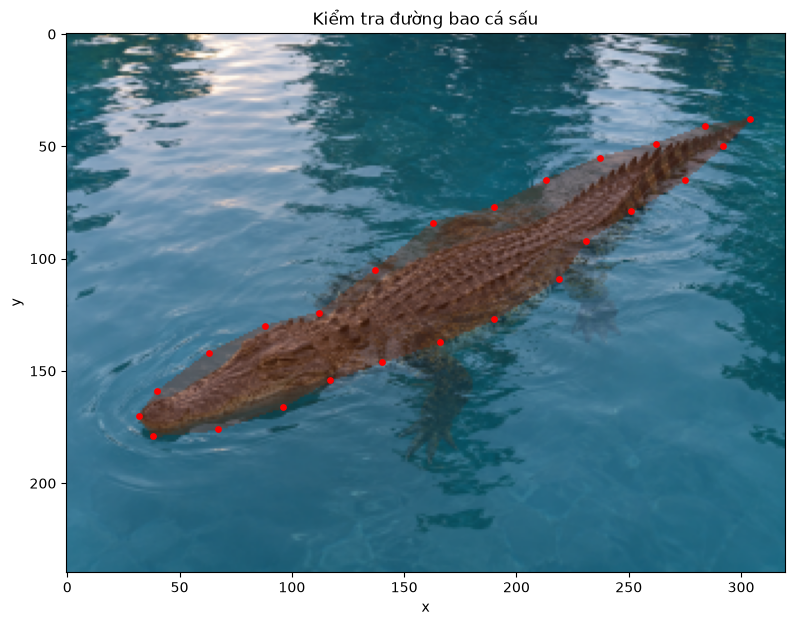

In [285]:
plt.figure(figsize=(10, 7))
plt.imshow(source_small)
plt.imshow(np.ma.masked_where(mask == 0, mask), cmap='Oranges',
           vmin=0, vmax=255, alpha=0.35)
plt.scatter(points[:, 0], points[:, 1], c='red', s=15)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Kiểm tra đường bao cá sấu')
plt.show()


## Chọn vị trí trên hồ bơi

**Input:** `target_small`, `source_small`, `mask`. **Output:** `mask_target` là mask đặt trong hệ tọa độ ảnh nền.


### Chọn góc trên trái của ảnh nguồn

`x`, `y` là vị trí góc trên trái của toàn bộ ảnh nguồn khi đặt lên nền, không phải tâm cá sấu.

Một pixel nguồn tại `(u, v)` sẽ nằm tại `(x + u, y + v)` trên nền. Ví dụ với vị trí bên dưới, điểm gần mõm `(32, 170)` sẽ nằm tại `(307, 550)`.

Thử vùng nước bên phải cô gái. Tăng `x` để dịch sang phải; tăng `y` để dịch xuống dưới.


In [286]:
x = 275
y = 380


### Kiểm tra vùng đặt có nằm trong nền

In [287]:
h, w = mask.shape
assert 0 < x and x + w < target_small.shape[1], 'Vùng đặt vượt mép ngang'
assert 0 < y and y + h < target_small.shape[0], 'Vùng đặt vượt mép dọc'


### Đặt mask vào tọa độ nền


In [288]:
mask_target = np.zeros(target_small.shape[:2], dtype=np.uint8)
mask_target[y:y+h, x:x+w] = mask


### Xem vị trí đường bao trên hồ bơi

Đường đỏ là biên mask tại vị trí đặt. Hình này giúp kiểm tra có chạm thành hồ, phao hoặc che cô gái không.


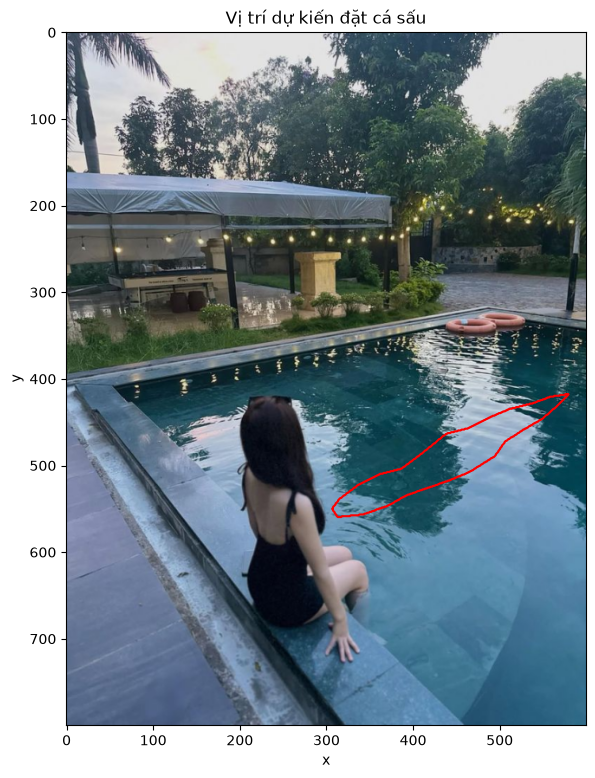

In [289]:
plt.figure(figsize=(7, 9))
plt.imshow(target_small)
plt.contour(mask_target, levels=[127.5], colors='red', linewidths=1.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Vị trí dự kiến đặt cá sấu')
plt.show()


## Ghép trực tiếp theo mask

Ghép trực tiếp là chép nguyên giá trị pixel cá sấu vào nền tại vị trí đã chọn. Chưa điều chỉnh màu, ánh sáng hoặc gradient.

**Input:** `target_small`, `source_small`, `mask`, `mask_target`, `x`, `y`. **Output:** `direct`, ảnh ghép trực tiếp dạng RGB, cùng kích thước ảnh nền.


### Chuẩn bị bản sao nền và vùng ghép

`.copy()` tạo mảng riêng để ghép mà không sửa `target_small`. `roi` là vùng hình chữ nhật trong `direct` đặt tại `(x, y)`.

Slice NumPy tạo một view: sửa `roi` sẽ sửa vùng tương ứng trong `direct`, vì cả hai dùng chung dữ liệu. Không gọi `.copy()` trên `roi` ở đây.

In [290]:
direct = target_small.copy()
h, w = mask.shape
roi = direct[y:y+h, x:x+w]


### Chép pixel nguồn trong mask

`mask > 0` tạo mảng boolean: `True` ở vùng chọn, `False` ở vùng ngoài. Dùng cùng mask để chọn các pixel tương ứng trong `roi` và `source_small`.

Mask có shape `(h, w)`, còn ảnh có shape `(h, w, 3)`. Chọn theo mask hai chiều sẽ lấy cả ba kênh của mỗi pixel được chọn.


In [291]:
roi[mask > 0] = source_small[mask > 0]


### Hiển thị ảnh ghép trực tiếp


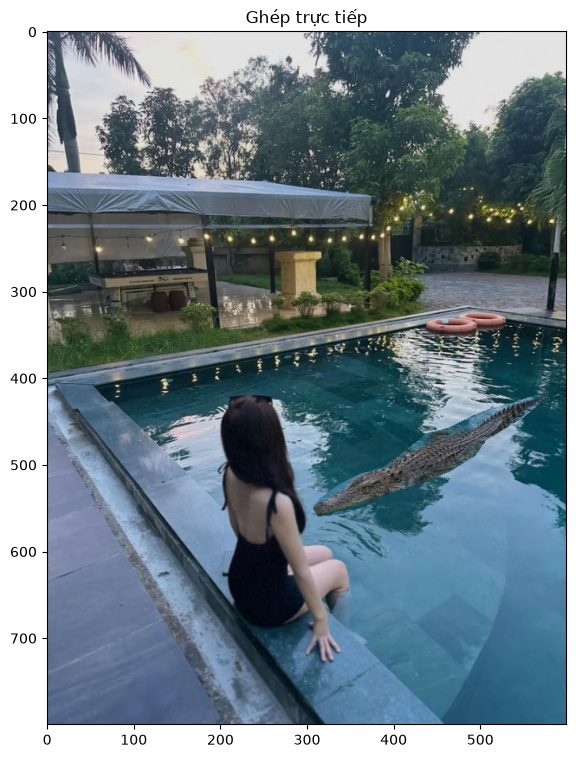

In [292]:
plt.figure(figsize=(7, 9))
plt.imshow(direct)
plt.title('Ghép trực tiếp')
plt.show()


### Kiểm tra pixel ngoài mask giữ nguyên

`mask_target == 0` chọn vùng ngoài đối tượng trong tọa độ nền. Kết quả bên dưới phải là `True`: các pixel này giống hệt nền trước khi ghép.


In [293]:
np.array_equal(direct[mask_target == 0], target_small[mask_target == 0])


True

## Gradient Domain Editing bằng OpenCV

Ghép trực tiếp chép nguyên pixel nguồn. Poisson blending tìm giá trị pixel phù hợp với nền dựa trên gradient nguồn và điều kiện biên từ nền. Chi tiết có thể được giữ trong khi màu, độ sáng thay đổi. Chưa dựng hệ phương trình ở bước này.

**Input:** `source_small`, `target_small`, `mask` và vị trí `(x, y)` đã dùng ở bước 2. **Output:** `blend`, ảnh ghép bằng `NORMAL_CLONE`, dạng RGB.

Giữ nguyên kích thước, mask và vị trí khi so sánh hai phương pháp.


### Tính điểm đặt cho OpenCV

`cv2.boundingRect(mask)` trả về `(mx, my, mw, mh)`: góc trên trái và kích thước hình chữ nhật nhỏ nhất bao vùng mask khác 0, trong tọa độ nguồn.

Với `NORMAL_CLONE`, OpenCV đặt hình chữ nhật này theo tâm `center` trên nền. Muốn khớp bản ghép trực tiếp, tính `center = (x + mx + mw // 2, y + my + mh // 2)`.

`// 2` là chia lấy phần nguyên, khớp cách OpenCV định vị ROI. Không dùng trực tiếp `(x, y)` hoặc tâm toàn bộ ảnh nguồn làm `center`.

In [294]:
mx, my, mw, mh = cv2.boundingRect(mask)
center = (x + mx + mw // 2, y + my + mh // 2)
center

(443, 489)

### Chạy NORMAL_CLONE


In [295]:
blend = cv2.seamlessClone(
    source_small, target_small, mask.copy(), center, cv2.NORMAL_CLONE
)


### Kiểm tra kích thước kết quả: phải trả về True


In [296]:
blend.shape == target_small.shape


True

### So sánh toàn ảnh

Hai hình dùng cùng vị trí ghép và cùng tỷ lệ hiển thị


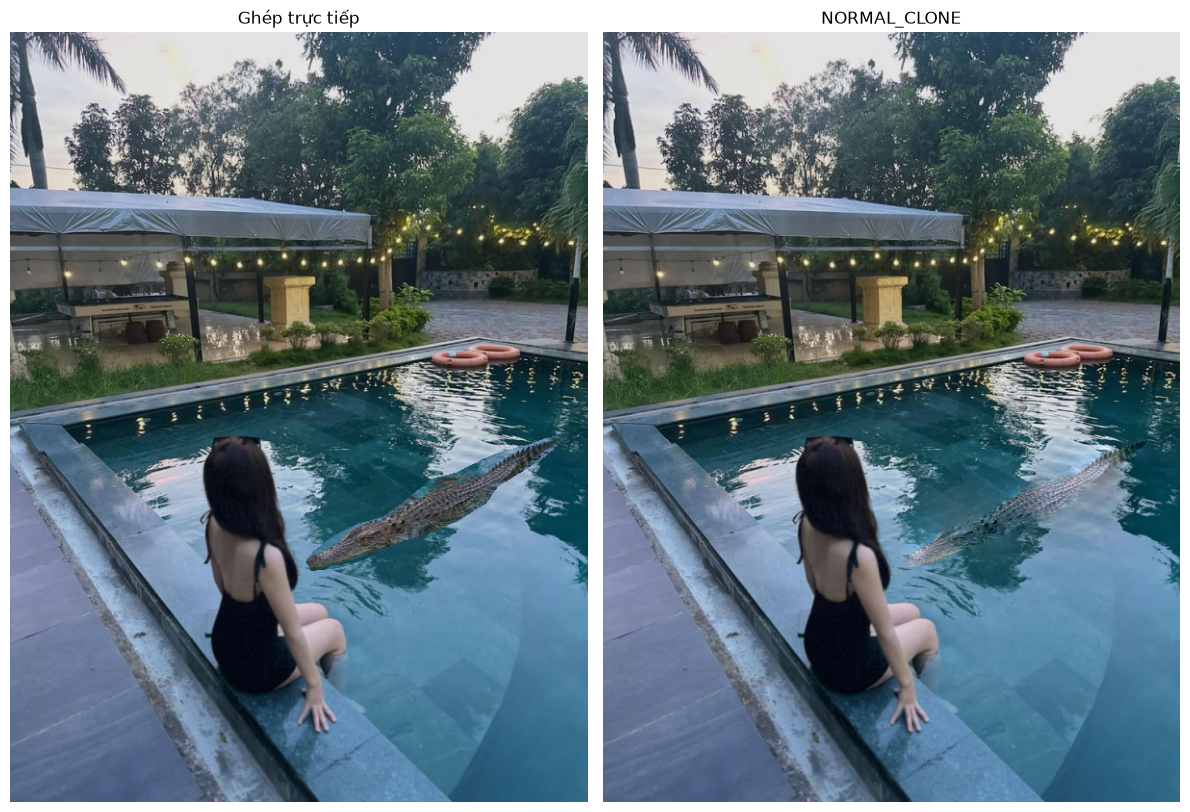

In [297]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
for ax, image, title in zip(axes, [direct, blend], ['Ghép trực tiếp', 'NORMAL_CLONE']):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


### Phóng to cùng vùng quanh cá sấu

Giới hạn hai trục giống nhau ở cả hai hình: vùng bounding box đã đặt trên nền, thêm 10 pixel mỗi phía. Trục `y` đi từ trên xuống nên giới hạn dưới viết trước giới hạn trên.


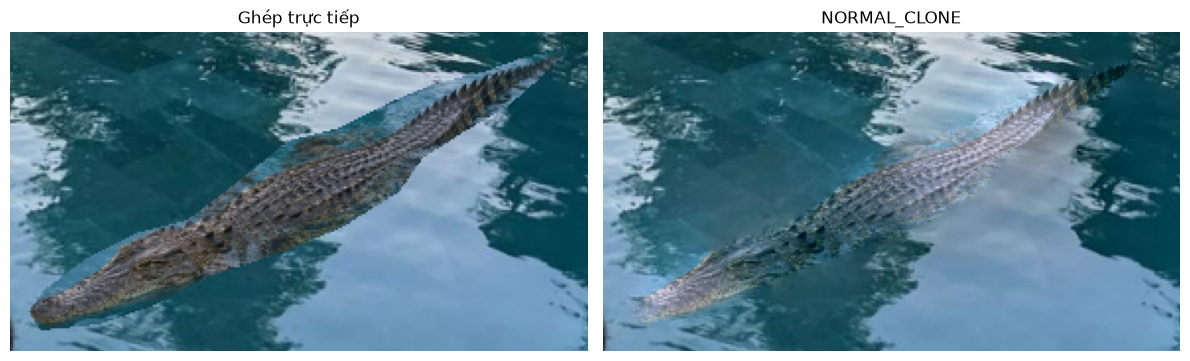

In [298]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, image, title in zip(axes, [direct, blend], ['Ghép trực tiếp', 'NORMAL_CLONE']):
    ax.imshow(image)
    ax.set_xlim(x + mx - 10, x + mx + mw + 10)
    ax.set_ylim(y + my + mh + 10, y + my - 10)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()
